In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
matches = pd.read_csv('../data/matches.csv')
deliveries = pd.read_csv('../data/deliveries.csv')

print("Matches shape:", matches.shape)
print("Deliveries shape:", deliveries.shape)

Matches shape: (1095, 20)
Deliveries shape: (260920, 17)


In [4]:
print(matches.columns.tolist())
print(deliveries.columns.tolist())

['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']
['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']


In [5]:
df = deliveries.merge(matches, left_on='match_id', right_on='id', how='left', suffixes=('', '_match'))

print(df.shape)
print(df.columns.tolist())
print(df.dtypes)

(260920, 37)
['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder', 'id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']
match_id              int64
inning                int64
batting_team         object
bowling_team         object
over                  int64
ball                  int64
batter               object
bowler               object
non_striker          object
batsman_runs          int64
extra_runs            int64
total_runs            int64
extras_type          object
is_wicket             int64
player_dismissed     object
dismissal_kind       object
fielder              object
id                    int64
season            

In [6]:
print("Number of seasons:", df['season'].nunique())
print(sorted(df['season'].unique()))

Number of seasons: 17
['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024']


In [7]:
print(df.isnull().sum()[df.isnull().sum() > 0])

extras_type         246795
player_dismissed    247970
dismissal_kind      247970
fielder             251566
city                 12397
player_of_match        490
winner                 490
result_margin         4124
target_runs            309
target_overs           309
method              257274
dtype: int64


In [8]:
print(df[df['city'].isnull()]['venue'].unique())

['Sharjah Cricket Stadium' 'Dubai International Cricket Stadium']


In [9]:
df.loc[df['venue'] == 'Sharjah Cricket Stadium', 'city'] = 'Sharjah'
df.loc[df['venue'] == 'Dubai International Cricket Stadium', 'city'] = 'Dubai'

print("Remaining missing city:", df['city'].isnull().sum())

Remaining missing city: 0


In [10]:
print((df[df['player_of_match'].isnull()]['id'].nunique()))
print((df[df['winner'].isnull()]['id'].nunique()))
print(df[df['player_of_match'].isnull()]['result'].value_counts())

5
5
result
no result    490
Name: count, dtype: int64


In [11]:
df['player_of_match'] = df['player_of_match'].fillna('No Result')
df['winner'] = df['winner'].fillna('No Result')

print(df['player_of_match'].isnull().sum(), df['winner'].isnull().sum())

0 0


In [12]:
df['dismissal_kind'] = df['dismissal_kind'].fillna('not out')

print(df['dismissal_kind'].isnull().sum())
print(df['dismissal_kind'].value_counts())

0
dismissal_kind
not out                  247970
caught                     8063
bowled                     2212
run out                    1114
lbw                         800
caught and bowled           367
stumped                     358
retired hurt                 15
hit wicket                   15
obstructing the field         3
retired out                   3
Name: count, dtype: int64


In [13]:
df['total_runs_check'] = df['batsman_runs'] + df['extra_runs']
mismatches = (df['total_runs_check'] != df['total_runs']).sum()
print("Number of mismatches:", mismatches)

Number of mismatches: 0


In [14]:
df.drop(columns=['total_runs_check'], inplace=True)

In [15]:
df['is_boundary'] = np.where(df['batsman_runs'] >= 4, 'boundary', 'non-boundary')

print(df['is_boundary'].value_counts())

is_boundary
non-boundary    217954
boundary         42966
Name: count, dtype: int64


In [16]:
print(df['over'].min(), df['over'].max())
print(df['ball'].min(), df['ball'].max())

0 19
1 11


In [18]:
print(df['over'].dtype)
print(df['over'].unique()[:10])

int64
[0 1 2 3 4 5 6 7 8 9]


In [ ]:
df['over_phase'] = np.select(conditions, choices, default='Unknown')

print(df['over_phase'].value_counts())

over_phase
Middle       119552
Powerplay     81905
Death         59463
Name: count, dtype: int64


In [21]:
df['date'] = pd.to_datetime(df['date'], format='mixed', dayfirst=False)

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

print(df['date'].dtype)
print(df[['date', 'year', 'month']].head())

datetime64[ns]
        date  year  month
0 2008-04-18  2008      4
1 2008-04-18  2008      4
2 2008-04-18  2008      4
3 2008-04-18  2008      4
4 2008-04-18  2008      4


In [22]:
top_batsmen = df.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(5)
print(top_batsmen)

batter
V Kohli      8014
S Dhawan     6769
RG Sharma    6630
DA Warner    6567
SK Raina     5536
Name: batsman_runs, dtype: int64


In [23]:
balls_per_bowler = df.groupby('bowler')['ball'].count()
eligible_bowlers = balls_per_bowler[balls_per_bowler >= 500].index

runs_conceded = df[df['bowler'].isin(eligible_bowlers)].groupby('bowler')['total_runs'].sum()
balls_bowled = df[df['bowler'].isin(eligible_bowlers)].groupby('bowler')['ball'].count()

economy_rate = np.round((runs_conceded / balls_bowled) * 6, 2)
economy_rate = economy_rate.sort_values()

print(economy_rate.head(10))

bowler
A Kumble          6.65
M Muralitharan    6.70
SP Narine         6.76
DW Steyn          6.79
DL Vettori        6.83
Rashid Khan       6.91
J Botha           6.92
R Ashwin          6.97
MM Ali            7.01
SL Malinga        7.03
dtype: float64


In [25]:
m = matches.copy()

team1 = m[['season', 'team1']].rename(columns={'team1': 'team'})
team2 = m[['season', 'team2']].rename(columns={'team2': 'team'})
played = pd.concat([team1, team2])

played_count = played.groupby(['season', 'team']).size().reset_index(name='played')

wins = m.groupby(['season', 'winner']).size().reset_index(name='wins').rename(columns={'winner': 'team'})

win_pct = played_count.merge(wins, on=['season', 'team'], how='left')
win_pct['wins'] = win_pct['wins'].fillna(0)
win_pct['win_pct'] = np.round((win_pct['wins'] / win_pct['played']) * 100, 2)

top_team_per_season = win_pct.loc[win_pct.groupby('season')['win_pct'].idxmax()]
print(top_team_per_season[['season', 'team', 'played', 'wins', 'win_pct']])

      season                   team  played  wins  win_pct
6    2007/08       Rajasthan Royals      16    13    81.25
10      2009       Delhi Daredevils      15    10    66.67
21   2009/10         Mumbai Indians      16    11    68.75
24      2011    Chennai Super Kings      16    11    68.75
38      2012  Kolkata Knight Riders      17    12    70.59
47      2013         Mumbai Indians      19    13    68.42
54      2014        Kings XI Punjab      17    12    70.59
64      2015         Mumbai Indians      16    10    62.50
75      2016    Sunrisers Hyderabad      17    11    64.71
80      2017         Mumbai Indians      17    12    70.59
84      2018    Chennai Super Kings      16    11    68.75
96      2019         Mumbai Indians      16    11    68.75
104  2020/21         Mumbai Indians      16    11    68.75
108     2021    Chennai Super Kings      16    11    68.75
118     2022         Gujarat Titans      16    12    75.00
128     2023         Gujarat Titans      17    11    64.

In [26]:
m = matches.copy()
m['toss_winner_won'] = m['toss_winner'] == m['winner']

toss_summary = m.groupby(['season', 'toss_decision'])['toss_winner_won'].mean().reset_index()
toss_summary['win_pct'] = np.round(toss_summary['toss_winner_won'] * 100, 2)

print(toss_summary.head(10))

    season toss_decision  toss_winner_won  win_pct
0  2007/08           bat         0.346154    34.62
1  2007/08         field         0.593750    59.38
2     2009           bat         0.542857    54.29
3     2009         field         0.636364    63.64
4  2009/10           bat         0.538462    53.85
5  2009/10         field         0.476190    47.62
6     2011           bat         0.440000    44.00
7     2011         field         0.562500    56.25
8     2012           bat         0.405405    40.54
9     2012         field         0.486486    48.65


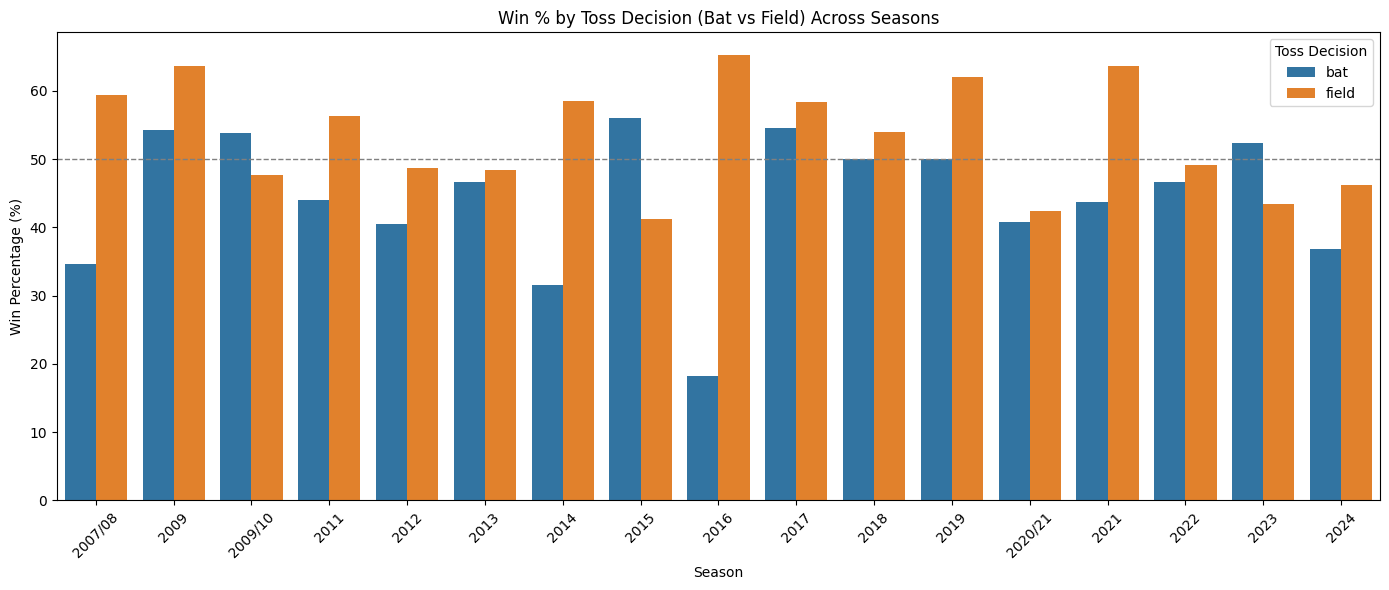

In [27]:
plt.figure(figsize=(14, 6))
sns.barplot(data=toss_summary, x='season', y='win_pct', hue='toss_decision')
plt.title('Win % by Toss Decision (Bat vs Field) Across Seasons')
plt.xlabel('Season')
plt.ylabel('Win Percentage (%)')
plt.xticks(rotation=45)
plt.legend(title='Toss Decision')
plt.axhline(50, color='gray', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

In [ ]:
# Toss Impact on Match Outcome: Across most seasons, teams that won the toss and chose to field first won more often than those who chose to bat first — 
# the advantage is especially pronounced from 2014 onward (e.g., 65% win rate for fielding in 2016 vs. just 18% for batting).
# A few seasons (2011, 2018, 2023) buck this trend. This supports the broader IPL narrative that chasing has become statistically favored,
# likely due to dew affecting bowling grip under lights and modern batting line-ups being well-suited to chasing known targets.

C:\Users\Harnoor kaur\AppData\Local\Temp\ipykernel_14308\3323099713.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10_batsmen.values, y=top10_batsmen.index, palette='viridis')


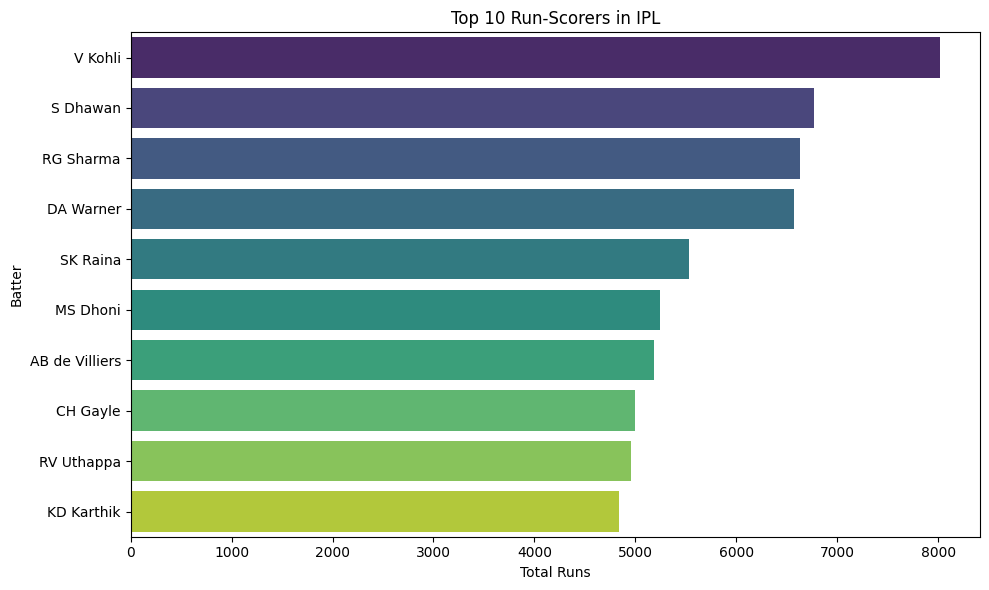

In [28]:
top10_batsmen = df.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top10_batsmen.values, y=top10_batsmen.index, palette='viridis')
plt.title('Top 10 Run-Scorers in IPL')
plt.xlabel('Total Runs')
plt.ylabel('Batter')
plt.tight_layout()
plt.show()

In [ ]:
# Top 10 run-scorers: V Kohli leads comfortably at over 8,000 runs, with a tight cluster of Dhawan, Sharma, and Warner around 6,500–6,800.
# The list is dominated by top-order batters/openers (Dhawan, Sharma, Warner, Gayle, Uthappa) who face the most balls, alongside middle-order anchors
# (Raina, Dhoni, de Villiers, Karthik) known for long IPL careers.

In [29]:
top3 = ['V Kohli', 'S Dhawan', 'RG Sharma']

dismissals = df[(df['player_dismissed'].isin(top3))]
dismissal_counts = dismissals.groupby(['player_dismissed', 'dismissal_kind']).size().reset_index(name='count')

pivot = dismissal_counts.pivot(index='player_dismissed', columns='dismissal_kind', values='count').fillna(0)

print(pivot)

dismissal_kind    bowled  caught  caught and bowled   lbw  retired hurt  \
player_dismissed                                                          
RG Sharma           27.0   157.0               10.0  15.0           0.0   
S Dhawan            40.0   112.0                3.0  13.0           1.0   
V Kohli             39.0   138.0                4.0  12.0           0.0   

dismissal_kind    run out  stumped  
player_dismissed                    
RG Sharma            11.0      3.0  
S Dhawan             16.0      8.0  
V Kohli               9.0      5.0  


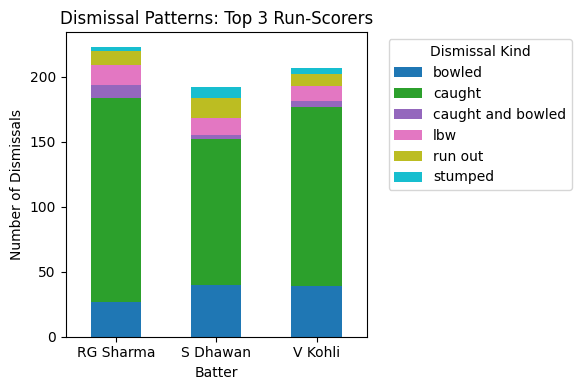

In [31]:
pivot = pivot.drop(columns=['retired hurt'], errors='ignore')

pivot.plot(kind='bar', stacked=True, figsize=(6, 4), colormap='tab10')
plt.title('Dismissal Patterns: Top 3 Run-Scorers')
plt.xlabel('Batter')
plt.ylabel('Number of Dismissals')
plt.legend(title='Dismissal Kind', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Dismissal patterns (top 3 run-scorers): All three are dismissed primarily by caught (60–75% of dismissals), reflecting their aggressive, 
# attacking styles. S Dhawan stands out with proportionally more run out dismissals than Kohli or Sharma, suggesting either more running mix-ups or 
# aggressive running between the wickets. lbw and bowled are fairly consistent across all three, indicating no major shared weakness against a specific 
# bowling mode — their vulnerability is overwhelmingly tied to shot selection leading to catches, not technical flaws against particular deliveries.

In [32]:
runs_per_season = df.groupby('season')['total_runs'].sum()
matches_per_season = matches.groupby('season')['id'].nunique()

avg_runs_per_match = (runs_per_season / matches_per_season).reset_index()
avg_runs_per_match.columns = ['season', 'avg_runs']

print(avg_runs_per_match)

     season    avg_runs
0   2007/08  309.258621
1      2009  286.894737
2   2009/10  314.716667
3      2011  289.780822
4      2012  303.418919
5      2013  297.394737
6      2014  315.516667
7      2015  311.067797
8      2016  314.366667
9      2017  318.406780
10     2018  331.683333
11     2019  323.900000
12  2020/21  323.600000
13     2021  310.616667
14     2022  329.662162
15     2023  347.135135
16     2024  365.788732


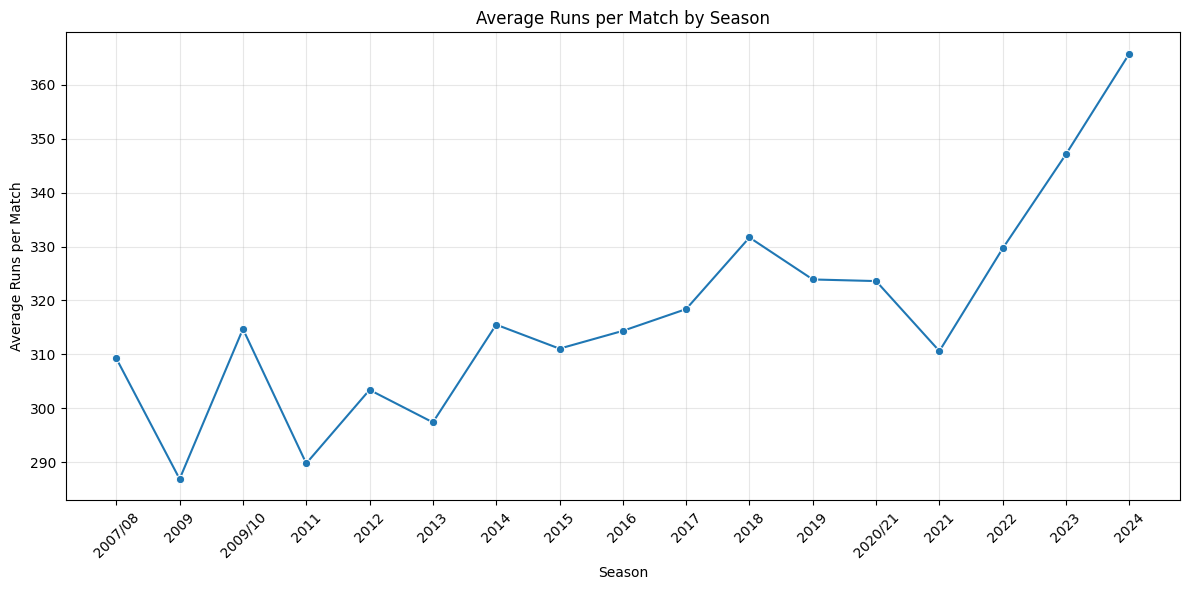

In [33]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=avg_runs_per_match, x='season', y='avg_runs', marker='o')
plt.title('Average Runs per Match by Season')
plt.xlabel('Season')
plt.ylabel('Average Runs per Match')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Seasonal batting trends: Average runs per match fluctuated considerably in the early IPL years (2008–2014, ranging 287–315), 
# then shows a clear sustained rise from 2021 onward, peaking at 365.8 runs/match in 2024 — the highest in IPL history. 
# 2009 was the lowest-scoring season (286.9), likely linked to it being played entirely in South Africa on different pitch conditions.

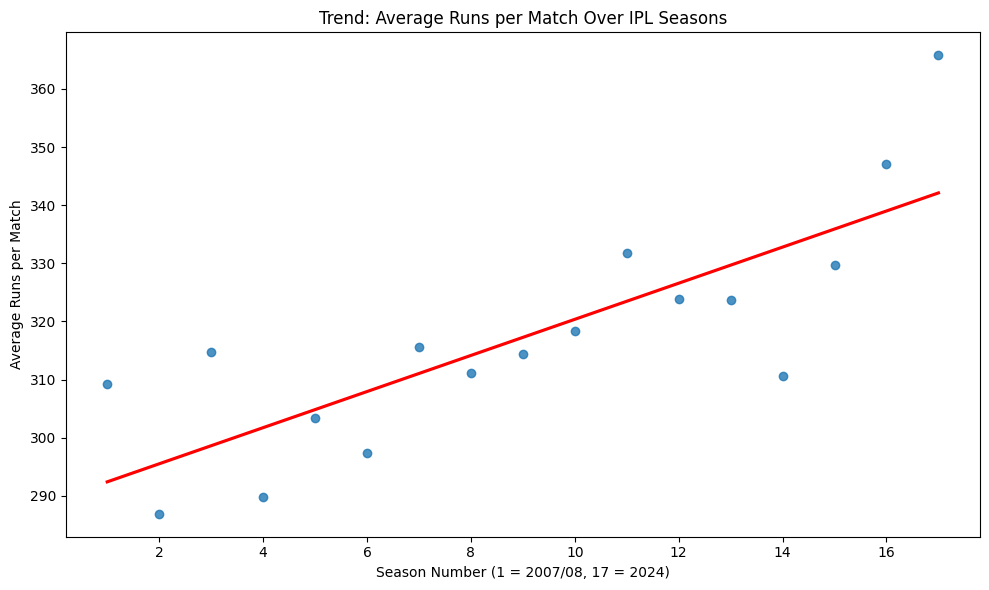

In [34]:
avg_runs_per_match['season_num'] = range(1, len(avg_runs_per_match) + 1)

plt.figure(figsize=(10, 6))
sns.regplot(data=avg_runs_per_match, x='season_num', y='avg_runs', ci=None, line_kws={'color': 'red'})
plt.title('Trend: Average Runs per Match Over IPL Seasons')
plt.xlabel('Season Number (1 = 2007/08, 17 = 2024)')
plt.ylabel('Average Runs per Match')
plt.tight_layout()
plt.show()

In [ ]:
# Trend confirmation: The regression line shows a clear positive slope, rising from roughly 293 runs/match (early seasons) to 342 (recent seasons) 
# on the fitted trend. Combined with the line plot, this confirms IPL is becoming more high-scoring over time — likely driven by better pitches, 
# shorter boundaries, evolving batting techniques (more 360-degree hitting), and rule changes (impact player rule in 2023 added an extra specialist 
# batter/bowler per side).

In [36]:
top5_venues = matches['venue'].value_counts().head(5)
print(top5_venues)

venue
Eden Gardens                                 77
Wankhede Stadium                             73
M Chinnaswamy Stadium                        65
Feroz Shah Kotla                             60
Rajiv Gandhi International Stadium, Uppal    49
Name: count, dtype: int64


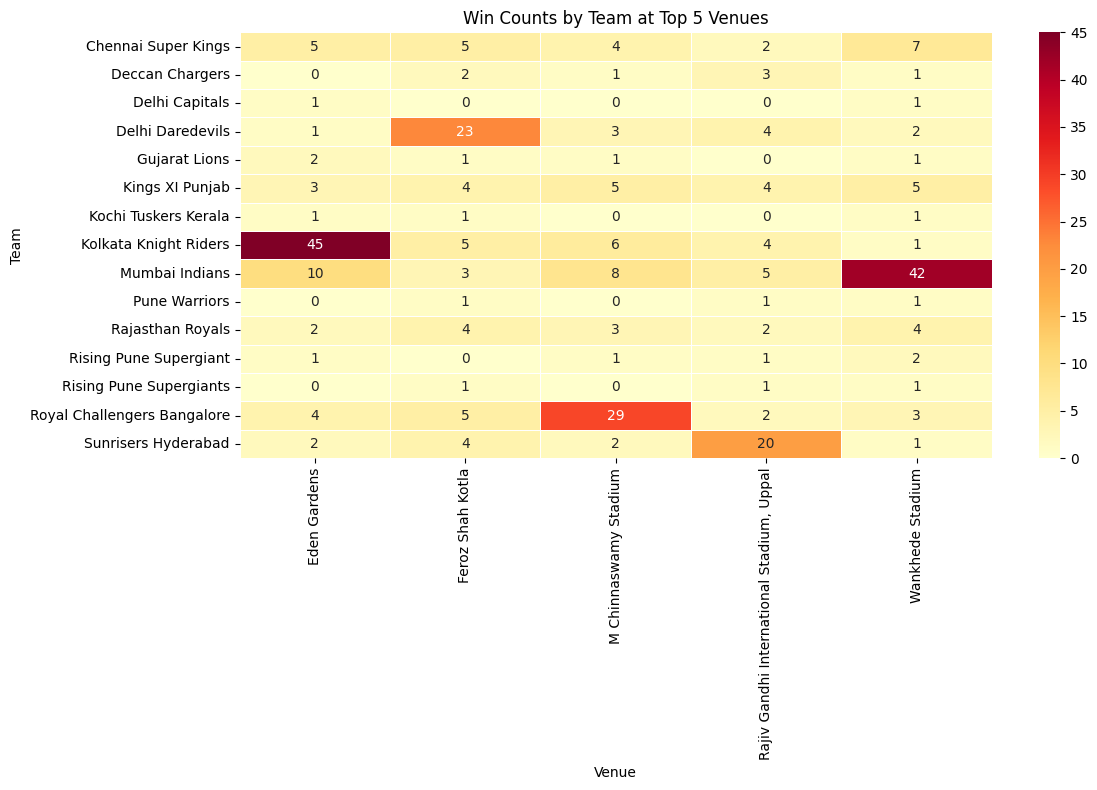

In [37]:
top5_venue_names = top5_venues.index.tolist()

venue_matches = matches[matches['venue'].isin(top5_venue_names)]
win_counts = venue_matches.groupby(['venue', 'winner']).size().reset_index(name='wins')

heatmap_data = win_counts.pivot(index='winner', columns='venue', values='wins').fillna(0)

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('Win Counts by Team at Top 5 Venues')
plt.xlabel('Venue')
plt.ylabel('Team')
plt.tight_layout()
plt.show()

In [38]:
death_overs = df[df['over'] >= 15]

death_runs_by_team = death_overs.groupby('batting_team')['total_runs'].sum().sort_values(ascending=False)
print(death_runs_by_team.head(6))

batting_team
Mumbai Indians                 11889
Chennai Super Kings            11094
Royal Challengers Bangalore    10514
Kolkata Knight Riders          10123
Rajasthan Royals                9133
Kings XI Punjab                 7875
Name: total_runs, dtype: int64


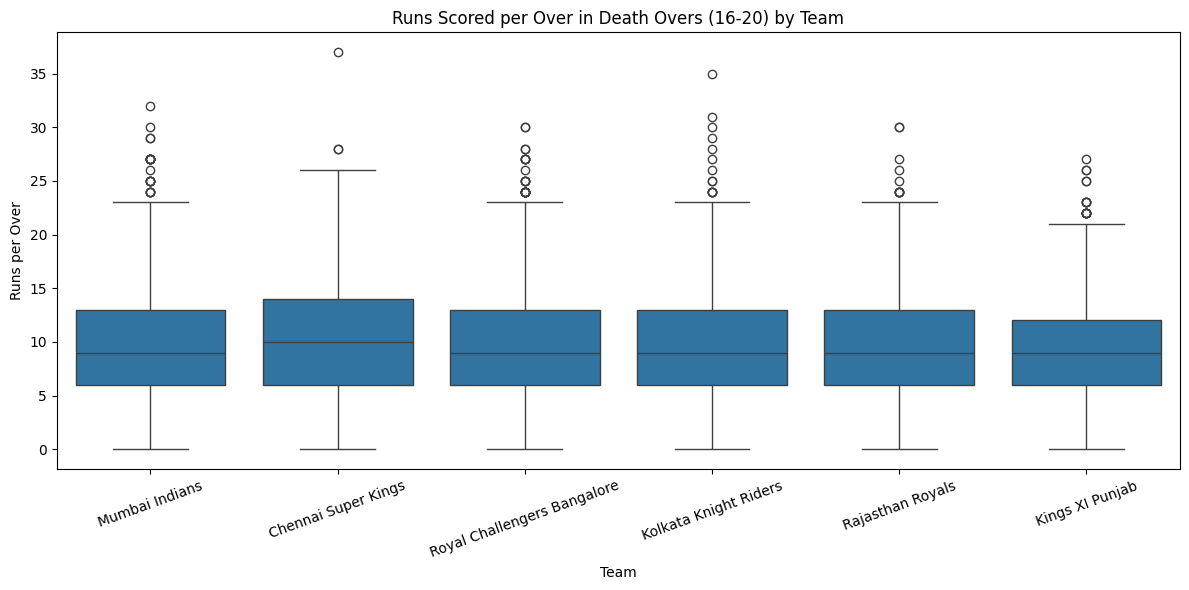

In [39]:
top6_teams = death_runs_by_team.head(6).index.tolist()

death_top6 = death_overs[death_overs['batting_team'].isin(top6_teams)]

runs_per_over = death_top6.groupby(['match_id', 'over', 'batting_team'])['total_runs'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.boxplot(data=runs_per_over, x='batting_team', y='total_runs', order=top6_teams)
plt.title('Runs Scored per Over in Death Overs (16-20) by Team')
plt.xlabel('Team')
plt.ylabel('Runs per Over')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [ ]:
# Death over performance: Chennai Super Kings shows the most explosive death-over batting — highest median (10 runs/over) and widest spread 
# (IQR 6–14, whisker to 26, with an outlier reaching 37 runs in a single over). Kings XI Punjab is the most consistent but least explosive, 
# with the tightest box (6–12) and the shortest upper whisker (21) among the six teams. Mumbai Indians, RCB, KKR, and Rajasthan Royals are nearly 
# identical in their median (9) and IQR, differing mainly in occasional outlier overs (KKR has a notably high outlier cluster reaching 35).

Libraries imported successfully!
